In [1]:
# 27 January 2026
# Zachary Katz
# zachary_katz@mines.edu

"""
Example script to demonstrate radar specularity analysis workflow. A wet bed
or subglacial lake is likely to be more specular than a dry rough bed. Thus,
specularity provides another way to analyze subglacial hydrology. If repeat 
tracks are available, specularity can also be used to assess temporal changes in 
basal conditions.

This notebook loads offset video KRT2 (2018-2019) radar data collected over
Subglacial Lake Cheongsuk on David Glacier, Antarctica. A Hilbert transform is
applied to transform the data to complex space, and doppler spectra are computed
using a sliding window. A Sato filter is applied to threshold and compute
doppler spectra width and maximum frequency. The resulting widths are plotted
in map view over a prior outline of the lake.

Offset video data and example images from UTG is in ./_Data/UTG_1819_OffsetVideo
Subglacial Lake Cheongsuk outline is in ./_Data/SLD2

More background on radar specularity, see Schroeder et al., (2014)
https://doi.org/10.1109/LGRS.2014.2337878. This notebook uses doppler spectra
width as the estimate of specularity rather than the difference in coherent
power between different-sized apertures, described in Hills et al., (2026)
https://doi.org/10.1017/jog.2025.10122.
"""

# Imports and options
import os

import shapefile
import numpy as np
import xarray as xr
import scipy
import skimage

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs

%matplotlib inline

### MANUALLY SELECTED PARAMATERS ###
win_m = 750.0 # window length [m]
ovlp_m = 250.0 # overlap [m]

In [2]:
# Set paths and make output directory
offset_video_path = './_data/UTG_1819_OffsetVideo'
lake_path = './_data/SLD2'
outdir = './_Output'
os.makedirs(outdir, exist_ok=True)

# Helper functions
def compute_doppler_spectrum(radargram):
    """
    Compute doppler spectrum of radargram using hilbert transform.

    Parameters
    ----------
    radargram : Xarray.Dataframe
        UTIG radargram offset video

    Returns
    -------
    doppler_spectrum : np.ndarray
        2D array of doppler spectrum 
    """
    
    # Example coordinates at the bed
    start_y = 1200
    end_y = 1800
    start_x = 17500
    end_x = 18000

    # Get low gain band
    dat = radargram['bxds2'].compute().astype(np.float32)
    
    # Hilbert along fast_time axis
    analytic = scipy.signal.hilbert(dat, axis=1)
    data = analytic.T

    # Fast fourier transform
    data_for_fft = data[start_y:end_y:,start_x:end_x]
    data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)

    # Make frequency axis
    t = radargram['time'] 
    t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
    dt_slow = np.median(np.diff(t_sec.compute()))
    n_slow = data.shape[1]
    freq = np.fft.fftshift(
        np.fft.fftfreq(n_slow, d=dt_slow)
    )
    return freq, data_fft, start_y, end_y

def calc_doppler_ridge(freq, data_fft, start_y, end_y):
    """Use a Sato filter to extract the main band of a doppler spectrum.

    Parameters
    ----------
    freq : numpy.ndarray
        Frequency axis values of Fourier transform
    data_fft : numpy.ndarray
        2D fourier transform output
    start_y : float
        Starting y value of Fourier transform
    end_y : float
        Ending y value of Fourier transform

    Returns
    -------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    rad_db_sato : numpy.ndarray
        Sato-filtered and masked spectrum
    """

    # Transform radargram to log scale
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Filter for main band of spectrum and mask
    rad_db = scipy.ndimage.gaussian_filter(rad_db, sigma=(3,2))
    rad_db = skimage.filters.sato(rad_db, sigmas=range(10,15), black_ridges=False)
    mask = rad_db > (skimage.filters.threshold_otsu(rad_db))
    rad_db_sato = rad_db * mask

    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    return x, start_y + max_indices, rad_db_sato

def calc_width_and_max(x,y,threshold):
    """
    Find width and max of Sato-filtered doppler spectra.
    Start with y location of middle point, assumed to be in the main parabola 
    [valid unless severely sloping]. Work out in both directions until distance
    between point and prior point is greater than a threshold

    Parameters
    ----------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    threshold : float
        Gap tolerance in algorithm [ns]

    Returns
    -------
    x[right] : float
        Right edge x-value
    x[left] : float
        Left edge x-value
    x_at_max : float
        x-value at maximum y
    y_at_max : float
        Maximum y-value
    """

    y = -y # Flip direction convention (Depth increases downward)
    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Find right edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index < len(y)-1):
        next_index = starting_index + 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    right = (starting_index - 1)

    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Find left edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index > 0):
        next_index = starting_index - 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    left = (starting_index + 1)

    y_masked = y[left:right]
    
    # Return nan if no max found
    try:
        y_at_max = -np.max(y_masked)
        x_at_max = x[np.argmax(y_masked) + left]
    except:
        y_at_max = np.nan
        x_at_max = np.nan

    return x[right],x[left], x_at_max, y_at_max

def plot_doppler(freq, data_fft, start_y, end_y, ridge_params, rad_db_sato):
    """
    Plot doppler spectrum and Sato-filtered doppler spectrum with max and width
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Get doppler spectrum in dB
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Plot doppler spectrum
    im1 = ax1.imshow(rad_db, aspect='auto', cmap='gray', origin='lower', extent = [freq[0], freq[-1],start_y, end_y], vmin=-50, vmax=0)
    # Prettify ax1
    ax1.invert_yaxis()
    cb1 = fig.colorbar(im1, ax=ax1)
    ax1.set_ylabel("Fast Time [ns]",fontsize=16)
    ax1.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax1.tick_params(labelsize=14)
    cb1.ax.tick_params(labelsize=14)
    cb1.set_label("Amplitude [dB]", fontsize=16)

    # Plot Sato-filtered doppler spectrum
    im2 = ax2.imshow(rad_db_sato,aspect='auto', cmap='gray',origin='lower',extent = [freq[0], freq[-1],start_y, end_y])
   
    # Scatter maximum and width
    
    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    ax2.scatter(x, start_y + max_indices, color='red', s=10, marker='x')
    ax2.scatter(ridge_params['x_at_max'], ridge_params['y_at_max'], color='blue', s=100, marker='o')
    ax2.hlines(ridge_params['y_at_max'], ridge_params['left'], ridge_params['right'], colors='blue', linestyles='-', linewidth=2)
    
    # Prettify ax2
    ax2.invert_yaxis()
    cb2 = fig.colorbar(im2, ax=ax2, label="Amplitude [dB]")
    fig.tight_layout()
    ax2.set_ylabel("Fast Time [ns]",fontsize=16)
    ax2.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax2.tick_params(labelsize=14)
    cb2.ax.tick_params(labelsize=14)
    cb2.set_label("Sato [Thresholded]", fontsize=16)

    fig.tight_layout()
    return fig


def plot_radargram_planview_width(ax, xs_lake, ys_lake, plot_dict):
    """
    Plot doppler width and lake outline map view
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for x_center_list, y_center_list, plotting in zip(plotting_dict['x_centers'], plotting_dict['y_centers'], plotting_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        cb = ax.scatter(x_center_list, y_center_list, c=width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=25)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label("Doppler Width [Hz]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    #ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)

    return fig

In [3]:
# Load KRT2 offset video netcdf files
file_paths = [os.path.join(offset_video_path, f) for f in os.listdir(offset_video_path) if f.endswith('.nc')]

offset_video_radargrams = []
for f in file_paths:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams.append(offset_video_radargram)

offset_video_radargrams.sort(key=lambda x: x.transect_id)
offset_video_radargrams[0]


<xarray.Dataset> Size: 899MB
Dimensions:    (distance: 23382, fast_time: 3200)
Coordinates:
  * distance   (distance) float64 187kB 0.0 1.0 2.0 ... 2.338e+04 2.338e+04
  * fast_time  (fast_time) timedelta64[ns] 26kB 00:00:00 ... 00:00:00.000063980
Data variables:
    x          (distance) float64 187kB ...
    y          (distance) float64 187kB ...
    h          (distance) float64 187kB ...
    time       (distance) datetime64[ns] 187kB ...
    bxds7      (distance, fast_time) int16 150MB ...
    bxds6      (distance, fast_time) int16 150MB ...
    bxds5      (distance, fast_time) int16 150MB ...
    bxds1      (distance, fast_time) int16 150MB ...
    bxds8      (distance, fast_time) int16 150MB ...
    bxds2      (distance, fast_time) int16 150MB ...
Attributes: (12/13)
    transect_id:     D2DG/IBH0e/X10a
    history:         Created on Sun Jan  4 16:46:26 2026 by Duncan A. Young
    funding:         KOPRI/K-ROUTE
    expedition:      KRT2
    platform:        AS-350 helicopter
    radar:           HeRa
    ...              ...
    sample_rate_hz:  50000000.0
    chirp_start_hz:  17500000.0
    chirp_end_hz:    2500000.0
    lo_gain_dbm:     82.7
    high_gain_dbm:   128.7
    reference:       http://doi.org/10.26153/tsw/11620

In [4]:
# Example doppler spectrum and width calculation
freq, data_fft, start_y, end_y = compute_doppler_spectrum(offset_video_radargrams[0])
x_sato, y_sato, sato_thresholded = calc_doppler_ridge(freq, data_fft, start_y, end_y)
right, left, x_at_max, y_at_max = calc_width_and_max(x_sato, y_sato, threshold=100)


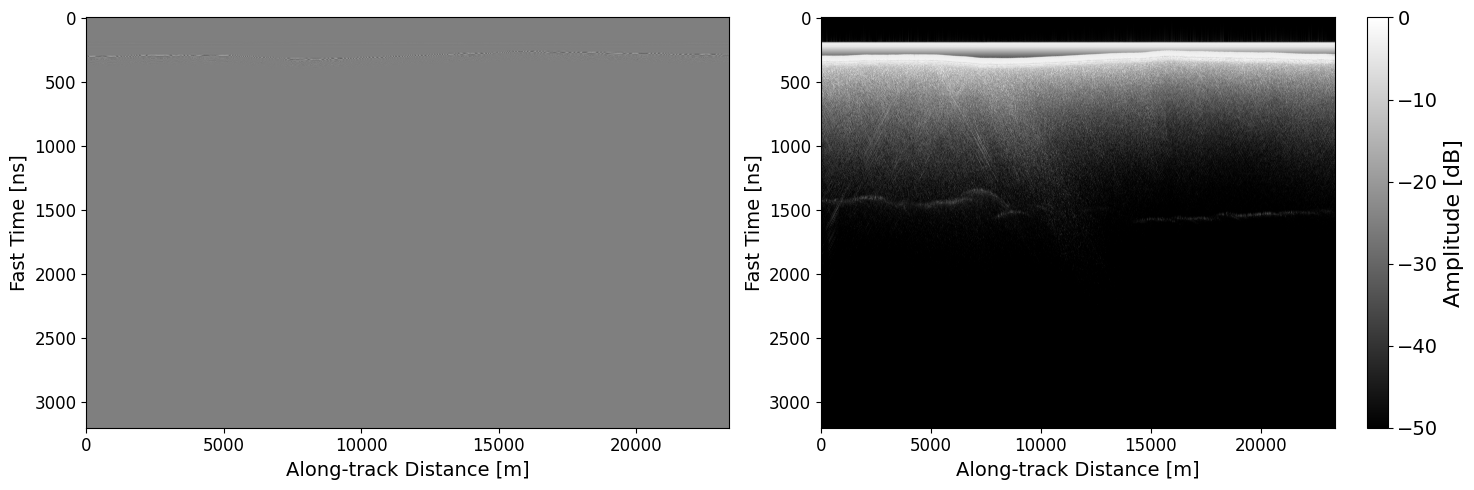

In [11]:
# Plot offset video and hilbert transform whith box around part used for doppler spectrum

fig, ax = plt.subplots(1,2, figsize=(15,5))
im = ax[0].imshow(offset_video_radargrams[0]['bxds2'].T, aspect='auto', cmap='gray', origin='lower')
ax[0].set_xlabel('Along-track Distance [m]', fontsize=14)
ax[0].set_ylabel('Fast Time [ns]', fontsize=14)
ax[0].tick_params(labelsize=12)
# Flip y-axis to have fast time increase downward
ax[0].invert_yaxis()
# Add box around doppler spectrum region

# Ax2 is hilbert transform
dat = offset_video_radargrams[0]['bxds2'].compute().astype(np.float32)

# Hilbert along fast_time axis
analytic = scipy.signal.hilbert(dat, axis=1)
data = analytic.T

eps = 1e-20
amp = np.abs(data)  
amp = amp / np.max(amp)
rad_db = 20 * np.log10(amp + eps)

im1 = ax[1].imshow(rad_db, aspect='auto', cmap='gray', origin='lower',vmin=-50, vmax=0)
ax[1].set_xlabel('Along-track Distance [m]', fontsize=14)
ax[1].set_ylabel('Fast Time [ns]', fontsize=14)
ax[1].tick_params(labelsize=12)
# Flip y-axis to have fast time increase downward
ax[1].invert_yaxis()
# Add box around doppler spectrum region
#rect = plt.Rectangle((17500, 1200), 500, 600, linewidth=1, edgecolor='red', facecolor='none')
#ax[1].add_patch(rect)
# Colorbar to ax[1]
cb1 = fig.colorbar(im1, ax=ax[1])
cb1.ax.tick_params(labelsize=14)
cb1.set_label("Amplitude [dB]", fontsize=16)


fig.tight_layout()

fig.savefig(os.path.join(outdir, 'OffsetVideo_Hilbert_Boxed.png'), dpi=300, bbox_inches='tight')




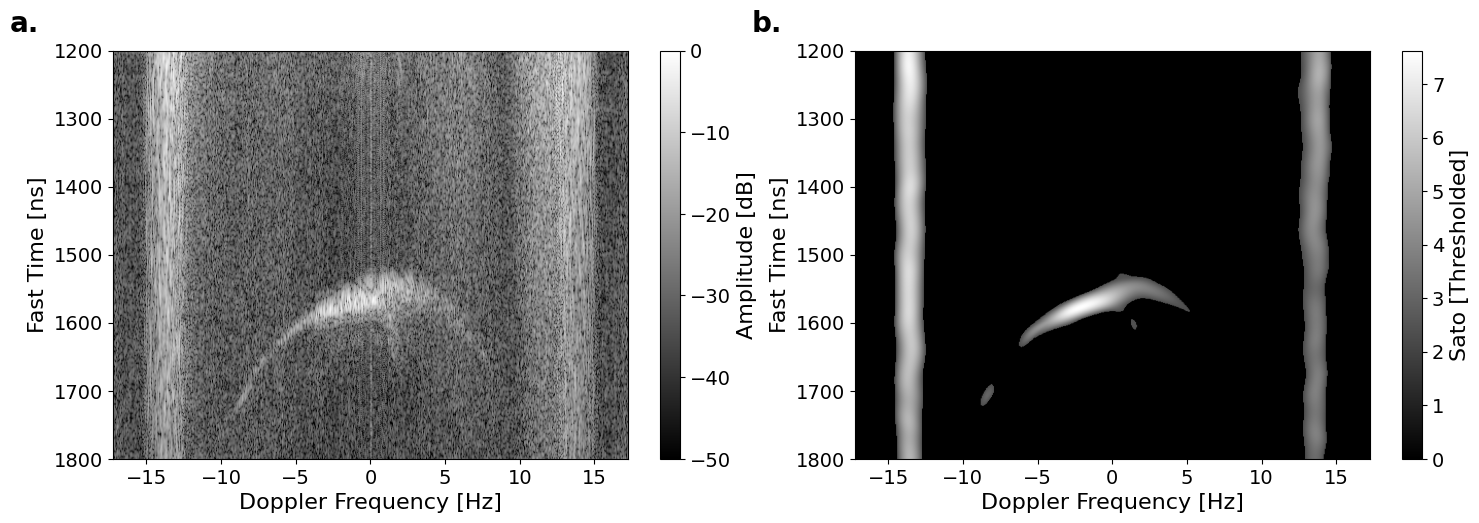

In [13]:
# Example plotting
ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}
doppler_fig = plot_doppler(freq, data_fft, start_y, end_y, ridge_params, sato_thresholded)
doppler_fig.axes[0].annotate(
    'a.',
    xy=(-0.2, 1.1),
    xycoords='axes fraction',
    va='top',
    ha='left',
    color='black',
    fontsize=20,
    fontweight='bold'
)

doppler_fig.axes[1].annotate(
    'b.',
    xy=(-0.2, 1.1),
    xycoords='axes fraction',
    va='top',
    ha='left',
    color='black',
    fontsize=20,
    fontweight='bold'
)
doppler_fig.tight_layout
doppler_fig.savefig(os.path.join(outdir, 'Example_Spectrum.png'), dpi=300, bbox_inches='tight')

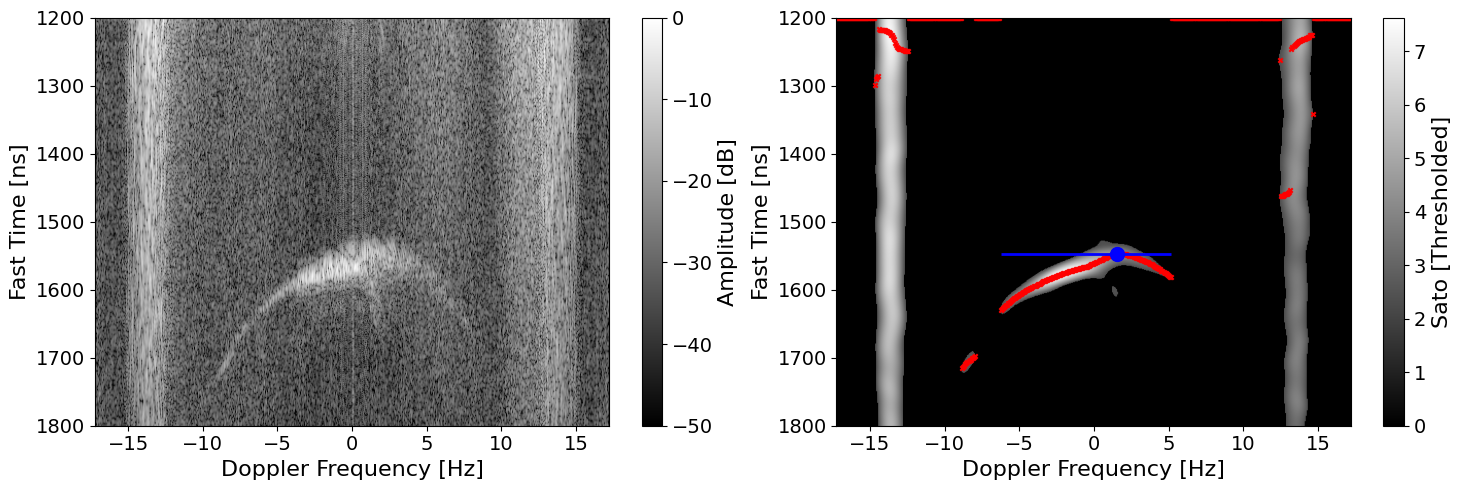

In [16]:
# Example plotting ppt
ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}
doppler_fig = plot_doppler(freq, data_fft, start_y, end_y, ridge_params, sato_thresholded)
doppler_fig.tight_layout
doppler_fig.savefig(os.path.join(outdir, 'Example_Spectrum_PPT.png'), dpi=300, bbox_inches='tight')

In [5]:
# TODO: Refactor storage method to avoid lists of lists!

# Loop over radargrams, loop over windows, and compute specularity
plotting_dict = {'x_centers':[], 'y_centers':[],'ridge_params_list':[]}
for radargram in offset_video_radargrams[:]:
    print(radargram.transect_id)
    # Extract hilbert transform and low gain band
    dat = radargram['bxds2'].compute().astype(np.float32)
    analytic = scipy.signal.hilbert(dat, axis=1)
    data = analytic.T

    # Compute frequency axis
    x_at = radargram['distance'].compute().values  # meters
    dx = np.median(np.diff(x_at))
    win_n = int(win_m / dx)
    step_n = int((win_m - ovlp_m) / dx)

    dt_slow = np.median(np.diff((radargram['time'] - radargram['time'][0]).astype('timedelta64[ns]').astype(np.float64).compute())) * 1e-9
    freq = np.fft.fftshift(np.fft.fftfreq(win_n, d=dt_slow))

    # Chose y range that encompasses bed and in y
    start_y = 1200
    end_y = 1800
    data_for_plot = data[start_y:end_y:,:]
    dist_at = radargram['distance'].compute().values  # meters
    dist_at = dist_at[:]
    x_at = radargram['x'].compute().values  # meters
    x_at = x_at[:]
    y_at = radargram['y'].compute().values  # meters
    y_at = y_at[:]
    data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
    window = scipy.signal.windows.hann(win_n)

    # Lists of variables to save for each window
    doppler_cubes = []     # list of [range, doppler]
    x_centers = []         # along-track center positions, x
    y_centers = []         # along-track center positions, y

    # Loop over slow-time windows and compute doppler spectra
    for start in range(0, data.shape[1] - win_n + 1, step_n):
        stop = start + win_n
        # Crop in x amd fourier transform
        data_win = data[:, start:stop]
        data_win = data_win * window[None, :]
        fft_win = np.fft.fftshift(np.fft.fft(data_win, axis=1),axes=1)

        # Store results
        doppler_cubes.append(fft_win)
        x_centers.append(np.mean(x_at[start:stop]))
        y_centers.append(np.mean(y_at[start:stop]))

    # Compute resulting doppler spectra widths and maximums
    ridge_params_list = []
    for cube in doppler_cubes[:]:
        x_sato, y_sato, sato_thresholded = calc_doppler_ridge(freq, cube, start_y, end_y)
        right, left, x_at_max, y_at_max = calc_width_and_max(x_sato, y_sato, threshold=100)
        
        # Store results
        ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}
        ridge_params_list.append(ridge_params)

    # Store as ragged array of arrays: 1st layer length = number of radargrams, 2nd layer length =numbers windows per radargram
    plotting_dict['x_centers'].append(x_centers)
    plotting_dict['y_centers'].append(y_centers)
    plotting_dict['ridge_params_list'].append(ridge_params_list)

D2DG/IBH0e/X10a
D2DG/IBH0e/X11a
D2DG/IBH0e/X12a
D2DG/IBH0e/X13a
D2DG/IBH0e/X14a
D2DG/IBH0e/X15a
D2DG/IBH0e/X17a
D2DG/IBH0e/X18a
D2DG/IBH0e/X19a
D2DG/IBH0e/X20a
D2DG/IBH0e/X21a
D2DG/IBH0e/X21b
D2DG/IBH0e/X22a
D2DG/IBH0e/X23a
D2DG/IBH0e/X24a
D2DG/IBH0e/X25a
D2DG/IBH0e/X26a
D2DG/IBH0e/X27a
D2DG/IBH0e/X27b
D2DG/IBH0e/X28a
D2DG/IBH0e/X29a
D2DG/IBH0e/X30a
D2DG/IBH0e/X31a
D2DG/IBH0e/X32a
D2DG/IBH0e/X33a
D2DG/IBH0e/X34a
D2DG/IBH0e/X35a
D2DG/IBH0e/X37a
D2DG/IBH0g/Y22a
D2DG/IBH0g/Y23a
D2DG/IBH0g/Y24a
D2DG/IBH0g/Y25a
D2DG/IBH0g/Y26a
D2DG/IBH0g/Y27a
D2DG/IBH0g/Y28a
D2DG/IBH0g/Y29a
D2DG/IBH0g/Y30a
D2DG/IBH0g/Y31a
D2DG/IBH0g/Y32a
D2DG/IBH0g/Y33a
D2DG/IBH0g/Y34a
D2DG/IBH0g/Y35a


In [6]:
# Load Subglacial Lake Cheongsuk shapefile
pathA = lake_path + '/SLD2-A.shp'
pathB = lake_path + '/SLD2-B.shp'
pathC = lake_path + '/SLD2-C.shp'

xs_lake = []
ys_lake = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs_lake.append(x)
    ys_lake.append(y)


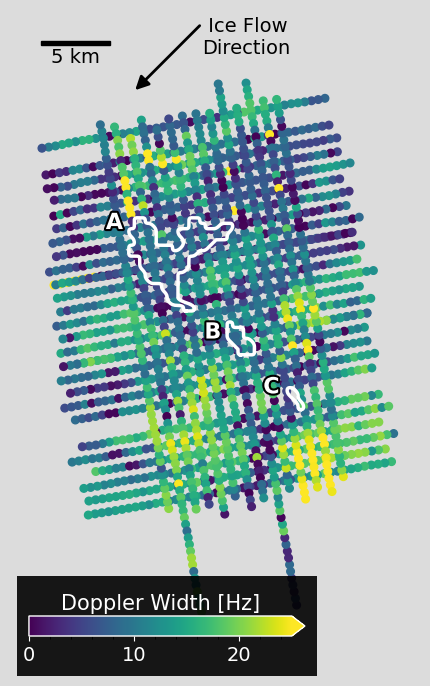

In [7]:
# Plot plan view comparison
import matplotlib.patheffects as pe
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

plot_radargram_planview_width(ax, xs_lake, ys_lake, plotting_dict)
scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

fig.savefig(os.path.join(outdir, 'Doppler_width_map.png'), dpi=300, bbox_inches='tight')



In [63]:
from cartopy.mpl.geoaxes import GeoAxes
def plot_radargram_planview_width_and_zoom(ax, xs_lake, ys_lake, plot_dict):
    """
    Plot doppler width and lake outline map view
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for x_center_list, y_center_list, plotting in zip(plotting_dict['x_centers'], plotting_dict['y_centers'], plotting_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        cb = ax.scatter(x_center_list, y_center_list, c=width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=25)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label("Doppler Width [Hz]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    #ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)

    # Replot with zoom on Lake C
    # Add subplot zoom
    x0 = bbox[2]   # right edge
    y0 = bbox[1]   # bottom edge
    shiftx = 500
    shifty = 3500
    x0 += shiftx
    y0 -= shifty
    # Size of inset in map units (tweak these)
    ext = [665500, 670500, -1467000, -1459000]
    inset_height = 1.5*(ext[3] - ext[2])
    inset_width  = 1.5* (ext[1] - ext[0])

    axins = ax.inset_axes(
        [x0 - inset_width,
        y0,
        inset_width,
        inset_height],
        transform=ax.transData,
        projection=ps71_projection,   # <-- ONLY projection
        zorder=20,

    )
    axins.set_extent(ext, crs=ps71_projection)
    for spine in axins.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    axins.set_facecolor('gainsboro')

    for x_center_list, y_center_list, plotting in zip(plotting_dict['x_centers'], plotting_dict['y_centers'], plotting_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        axins.scatter(x_center_list, y_center_list, c=width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=25)
    # Add rectangle to main plot to show zoom area
    rect = plt.Rectangle((ext[0], ext[2]), ext[1]-ext[0], ext[3]-ext[2], linewidth=2, edgecolor='black', facecolor='none', zorder=10)
    ax.add_patch(rect)

    return fig

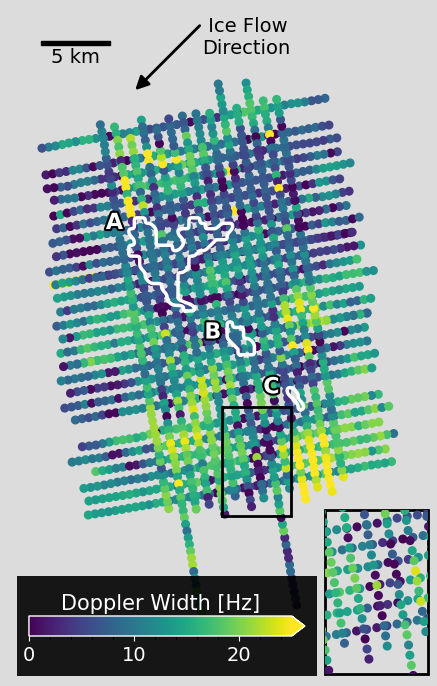

In [64]:
# Replot with zoom on Lake C
import matplotlib.patheffects as pe
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

plot_radargram_planview_width_and_zoom(ax, xs_lake, ys_lake, plotting_dict)
scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax.add_artist(scalebar)

#bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent
# Glacial Flow Direction Arrow
ax.annotate(
    '',
    xy=(659000, -1436000),      # arrow tip (downstream)
    xytext=(664000, -1431000),  # arrow tail
    arrowprops=dict(
        arrowstyle='-|>',       # filled arrow head
        color='black',
        lw=2,
        mutation_scale=20 ,      # controls head size
    ),
    transform=ps71_projection,
    zorder=10
)

ax.text(664000, -1432000, ' Ice Flow\nDirection',
        fontsize=14, color='black', ha='left', va='center',zorder=10)

# Lakeb lakes A, B, C
ax.annotate('A', xy=(657000, -1446000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('B', xy=(664200, -1454000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection, zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.annotate('C', xy=(668500, -1458000), color='white', fontsize=16, fontweight='bold',transform=ps71_projection,zorder=10,path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Set background gainsboro
fig.patch.set_facecolor('gainsboro')

fig.savefig(os.path.join(outdir, 'Doppler_width_map_zoom.png'), dpi=300, bbox_inches='tight')




In [70]:
# Get mean doppler width over lakes vs rest of area
import shapely.geometry

lake_widths = []
nonlake_widths = []
for x_center_list, y_center_list, plotting in zip(plotting_dict['x_centers'], plotting_dict['y_centers'], plotting_dict['ridge_params_list']):
    for x_center, y_center, rp in zip(x_center_list, y_center_list, plotting):
        width = rp['right'] - rp['left']
        # Check if point is in lake
        for x_lake, y_lake in zip(xs_lake, ys_lake):
            lake_poly = shapely.geometry.Polygon(zip(x_lake, y_lake))
            point = shapely.geometry.Point(x_center, y_center)
            if lake_poly.contains(point):
                lake_widths.append(width)
            else:
                nonlake_widths.append(width)

In [72]:
print(np.unique(lake_widths))
print(np.unique(nonlake_widths))
print(f"Mean lake doppler width: {np.nanmean(lake_widths)} Hz")
print(f"Mean non-lake doppler width: {np.nanmean(nonlake_widths)} Hz")

[ 0.40756914  0.53724054  0.68376068  0.88008801  0.96969697  1.02564103
  1.25150421  1.36752137  1.51404151  1.82912154  2.16606498  2.58852259
  2.73504274  3.46570397  3.56197353  3.71747212  3.9157373   4.18390805
  4.28399519  4.46026097  4.4765343   4.83018868  4.9070632   4.92849285
  4.96551724  5.34296029  5.35315985  5.39215686  5.45654565  5.60099133
  5.63522013  5.72057206  5.74969021  6.07843137  6.26566416  6.34643377
  6.57471264  6.77871148  6.89655172  7.10334789  7.31034483  7.3944687
  7.43494424  7.43494424  7.49425287  7.51243781  7.56914119  7.77385159
  7.77385159  7.78666667  7.93060719  8.0349345   8.0608365   8.10945274
  8.22988506  8.50746269  8.51540616  8.66920152  8.67540029  8.67647059
  8.72727273  8.7745098   8.79184862  8.97058824  9.09305065  9.13165266
  9.15422886  9.24369748  9.46778711  9.65333333  9.77443609  9.78165939
  9.80392157  9.83523447  9.85994398  9.95633188 10.14705882 10.25210084
 10.42016807 10.45936396 10.49019608 10.49751244 10.